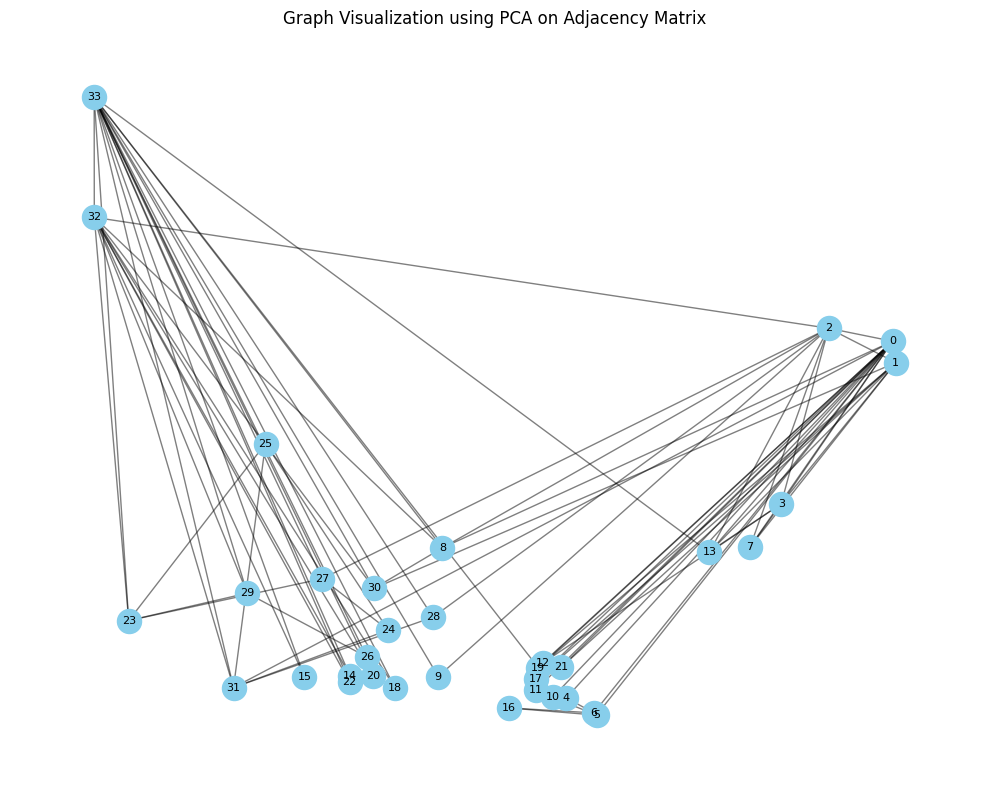

Explained variance by PC1: 23.00%
Explained variance by PC2: 17.61%
Total explained variance: 40.61%


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ساخت یک گراف نمونه
G = nx.karate_club_graph()  # گراف معروف کلوپ کاراته

# استخراج ماتریس مجاورت
adj_matrix = nx.adjacency_matrix(G).toarray()

# اعمال PCA برای کاهش ابعاد به 2 بعد
pca = PCA(n_components=2)
reduced_coords = pca.fit_transform(adj_matrix)

# ایجاد دیکشنری مختصات برای رسم گراف
pos = {i: reduced_coords[i] for i in range(len(reduced_coords))}

# رسم گراف در فضای کاهش‌یافته
plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='skyblue')
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Graph Visualization using PCA on Adjacency Matrix")
plt.axis('off')
plt.tight_layout()
plt.show()

# نمایش واریانس توضیح داده شده توسط هر مولفه
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance by PC1: {explained_variance[0]:.2%}")
print(f"Explained variance by PC2: {explained_variance[1]:.2%}")
print(f"Total explained variance: {sum(explained_variance):.2%}")

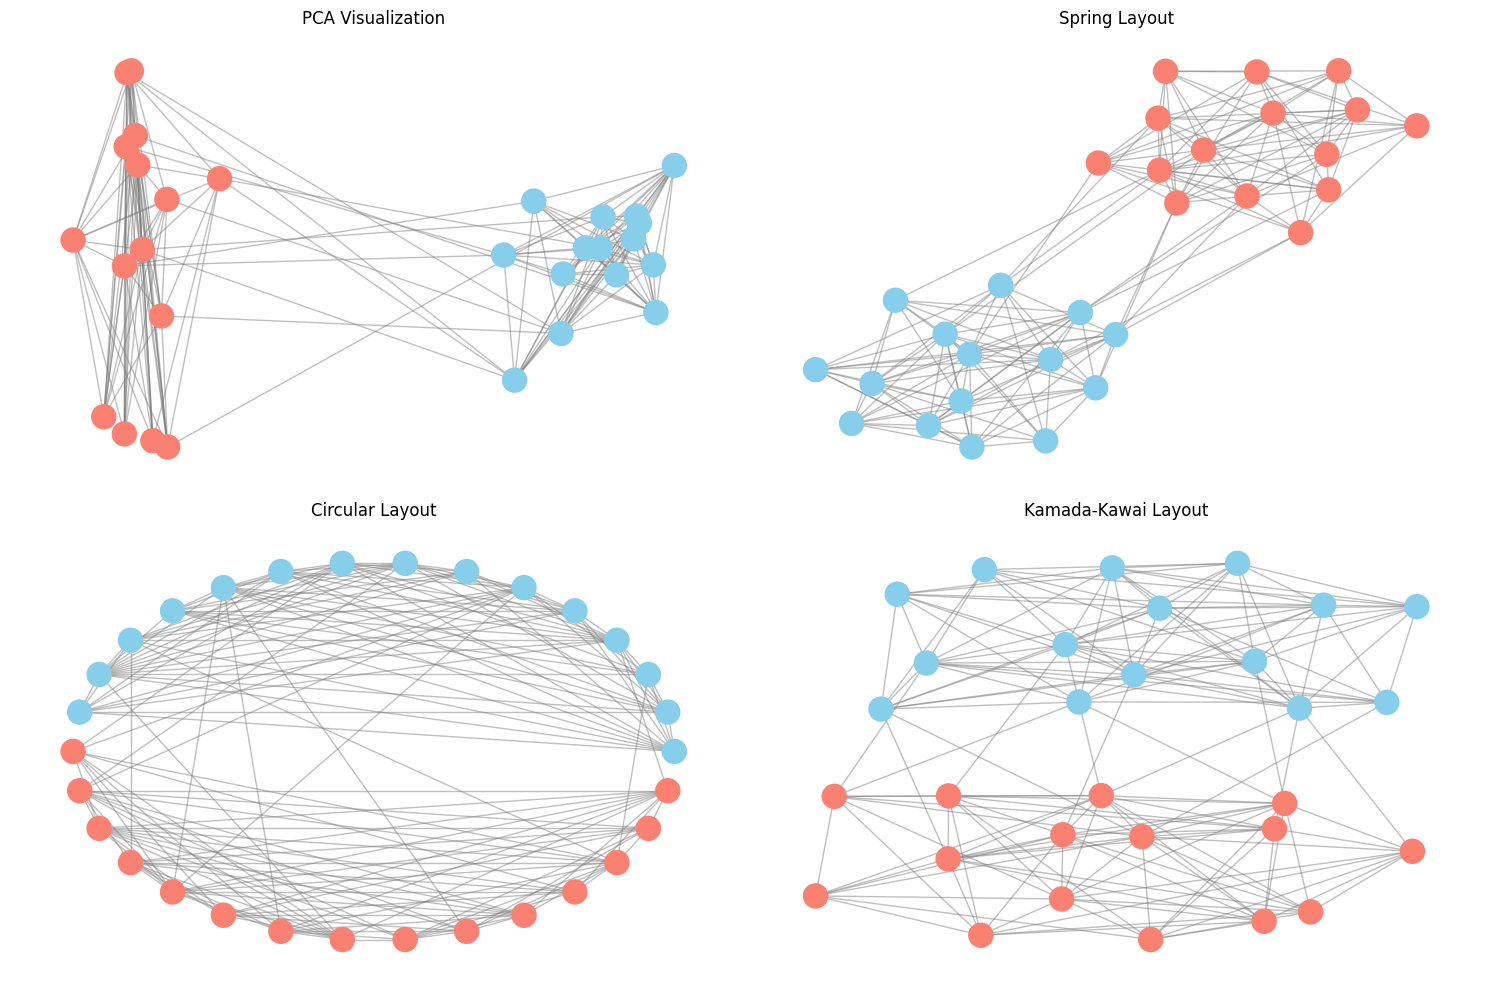

Explained variance by PC1: 43.43%
Explained variance by PC2: 7.89%
Total explained variance: 51.32%

Modularity of true communities: 0.4188
Modularity of PCA-based communities: 0.4188


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ساخت گراف با دو جامعه مشخص (استفاده از مدل بلوکی تصادفی)
n_communities = 2
community_sizes = [15, 15]  # دو جامعه با 15 نود در هر جامعه
p_in = 0.7  # احتمال اتصال درون جامعه
p_out = 0.05  # احتمال اتصال بین جوامع

# تولید گراف با ساختار جامعه‌ای
G = nx.stochastic_block_model(community_sizes, [[p_in, p_out], [p_out, p_in]], seed=42)

# استخراج ماتریس مجاورت
adj_matrix = nx.adjacency_matrix(G).toarray()

# نرمال‌سازی ماتریس قبل از PCA
# scaler = StandardScaler()
# adj_normalized = scaler.fit_transform(adj_matrix)

# اعمال PCA برای کاهش ابعاد به 2 بعد
pca = PCA(n_components=2)
# reduced_coords = pca.fit_transform(adj_normalized)
reduced_coords = pca.fit_transform(adj_matrix)

# ایجاد دیکشنری مختصات برای رسم گراف
pos_pca = {i: reduced_coords[i] for i in range(len(reduced_coords))}

# تعیین رنگ نودها بر اساس جامعه
node_colors = []
for i in range(len(G)):
    if i < community_sizes[0]:
        node_colors.append('skyblue')  # جامعه اول
    else:
        node_colors.append('salmon')   # جامعه دوم

# ایجاد دیکشنری رنگ‌ها
color_map = {i: node_colors[i] for i in range(len(G))}

# رسم گراف با استفاده از PCA
plt.figure(figsize=(15, 10))

# نمودار PCA
plt.subplot(2, 2, 1)
nx.draw_networkx_nodes(G, pos_pca, node_size=300, node_color=node_colors)
nx.draw_networkx_edges(G, pos_pca, alpha=0.5, edge_color='gray')
plt.title("PCA Visualization")
plt.axis('off')

# نمودار Spring Layout
plt.subplot(2, 2, 2)
pos_spring = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos_spring, node_size=300, node_color=node_colors)
nx.draw_networkx_edges(G, pos_spring, alpha=0.5, edge_color='gray')
plt.title("Spring Layout")
plt.axis('off')

# نمودار Circular Layout
plt.subplot(2, 2, 3)
pos_circular = nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos_circular, node_size=300, node_color=node_colors)
nx.draw_networkx_edges(G, pos_circular, alpha=0.5, edge_color='gray')
plt.title("Circular Layout")
plt.axis('off')

# نمودار Kamada-Kawai Layout
plt.subplot(2, 2, 4)
pos_kk = nx.kamada_kawai_layout(G)
nx.draw_networkx_nodes(G, pos_kk, node_size=300, node_color=node_colors)
nx.draw_networkx_edges(G, pos_kk, alpha=0.5, edge_color='gray')
plt.title("Kamada-Kawai Layout")
plt.axis('off')

plt.tight_layout()
plt.show()

# نمایش واریانس توضیح داده شده توسط هر مولفه
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance by PC1: {explained_variance[0]:.2%}")
print(f"Explained variance by PC2: {explained_variance[1]:.2%}")
print(f"Total explained variance: {sum(explained_variance):.2%}")

# محاسبه معیارهای کیفیت جامعه‌یابی
from networkx.algorithms.community import modularity

# پیش‌بینی جامعه بر اساس PCA
pca_labels = []
for i in range(len(G)):
    if reduced_coords[i, 0] < np.median(reduced_coords[:, 0]):
        pca_labels.append(0)
    else:
        pca_labels.append(1)

# محاسبه ماژولاریتی برای جامعه‌های واقعی و پیش‌بینی شده
true_communities = [0]*community_sizes[0] + [1]*community_sizes[1]
true_mod = modularity(G, [{i for i, c in enumerate(true_communities) if c == 0},
                         {i for i, c in enumerate(true_communities) if c == 1}])

pca_communities = [{i for i, c in enumerate(pca_labels) if c == 0},
                  {i for i, c in enumerate(pca_labels) if c == 1}]
pca_mod = modularity(G, pca_communities)

print(f"\nModularity of true communities: {true_mod:.4f}")
print(f"Modularity of PCA-based communities: {pca_mod:.4f}")

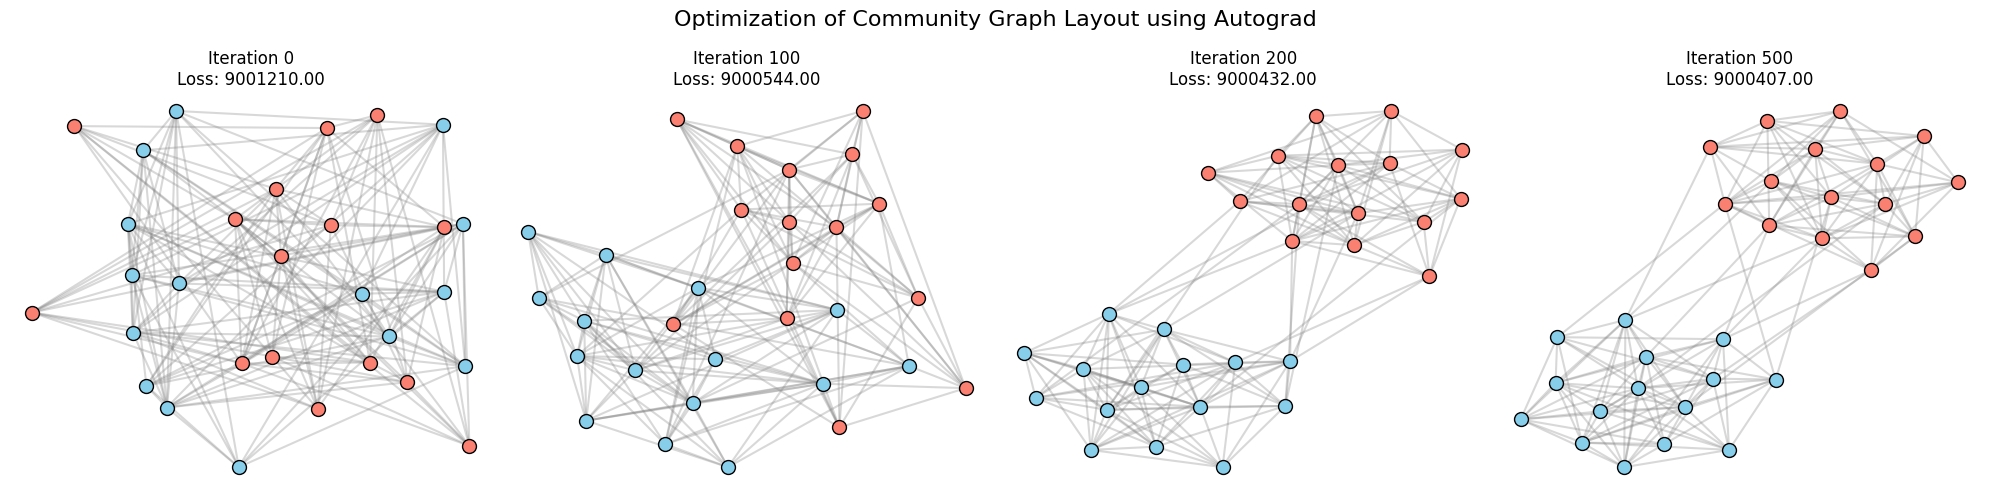

Average distance within communities: 0.8522
Average distance between communities: 2.5028
Separation ratio (between/within): 2.9367


In [2]:
import torch
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- 1. Setup Data: Create a Stochastic Block Model Graph ---
# Create a graph with two communities
n_communities = 2
community_sizes = [15, 15]  # Two communities with 15 nodes each
p_in = 0.7  # Probability of connection within communities
p_out = 0.05  # Probability of connection between communities

# Generate the graph with community structure
G = nx.stochastic_block_model(community_sizes, [[p_in, p_out], [p_out, p_in]], seed=42)
nodes = list(G.nodes())
node_to_idx = {node: i for i, node in enumerate(nodes)}
N = len(nodes)

# Convert edges to a tensor of shape (num_edges, 2)
edge_list = []
for u, v in G.edges():
    edge_list.append([node_to_idx[u], node_to_idx[v]])
edges = torch.tensor(edge_list, dtype=torch.long)

# --- 2. Initialize Coordinates Randomly ---
# X represents the (x, y) coordinates of our N nodes.
# We want to optimize X, so requires_grad=True.
torch.manual_seed(42)
X = torch.rand(N, 2, requires_grad=True)

# Using Adam optimizer (acts like Gradient Descent with momentum)
optimizer = torch.optim.Adam([X], lr=0.1)

# --- 3. Visualization Setup ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
steps_to_plot = [0, 100, 200, 500]  # Iterations to visualize

# Define node colors based on community
node_colors = []
for i in range(len(G)):
    if i < community_sizes[0]:
        node_colors.append('skyblue')  # Community 1
    else:
        node_colors.append('salmon')   # Community 2

# --- 4. Optimization Loop ---
for step in range(501):
    optimizer.zero_grad()
    
    # Calculate all pairwise differences: X_i - X_j
    # Shape becomes (N, N, 2) via broadcasting
    diff = X.unsqueeze(1) - X.unsqueeze(0)
    
    # Euclidean distance between all pairs
    # Add small epsilon to avoid division by zero
    dist = torch.norm(diff, dim=2) + 1e-6
    
    # --- The Energy Function ---
    
    # 1. Attraction: Minimize distance for connected edges
    # We gather distances only for pairs present in 'edges'
    edge_distances = dist[edges[:, 0], edges[:, 1]]
    loss_attraction = (edge_distances ** 2).sum()
    
    # 2. Repulsion: Maximize distance for ALL pairs (inverse distance)
    # We ignore the diagonal (distance to self is 0) by masking or just sum all
    # Since 1/0 is handled by epsilon, we sum everything.
    loss_repulsion = (1.0 / dist).sum()
    
    # 3. Community Separation: Add a term to encourage separation between communities
    # We'll add a repulsive force between nodes from different communities
    community_loss = 0
    for i in range(N):
        for j in range(N):
            # Only consider pairs from different communities
            if (i < community_sizes[0] and j >= community_sizes[0]) or \
               (i >= community_sizes[0] and j < community_sizes[0]):
                # Add repulsive force between communities
                community_loss += 1.0 / dist[i, j]
    
    # Total Loss: Combine forces
    # We weigh repulsion and community separation less to keep the graph compact
    loss = loss_attraction + 0.3 * loss_repulsion + 0.2 * community_loss
    
    # --- Autograd Magic ---
    loss.backward()
    optimizer.step()
    
    # --- Plotting ---
    if step in steps_to_plot:
        idx = steps_to_plot.index(step)
        ax = axes[idx]
        
        # Detach tensor to numpy for plotting
        pos = X.detach().numpy()
        
        # Draw edges
        for e in edge_list:
            p1, p2 = pos[e[0]], pos[e[1]]
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'gray', alpha=0.3, zorder=1)
            
        # Draw nodes with community colors
        for i in range(N):
            ax.scatter(pos[i, 0], pos[i, 1], c=node_colors[i], s=100, 
                      edgecolors='black', zorder=2)
        
        ax.set_title(f"Iteration {step}\nLoss: {loss.item():.2f}")
        ax.axis('off')

plt.suptitle("Optimization of Community Graph Layout using Autograd", fontsize=16)
plt.tight_layout()
plt.show()

# --- 5. Evaluate Community Separation ---
# Calculate the average distance between nodes within communities vs. between communities
pos = X.detach().numpy()
within_community_dist = 0
between_community_dist = 0
within_count = 0
between_count = 0

for i in range(N):
    for j in range(i+1, N):
        dist_ij = np.linalg.norm(pos[i] - pos[j])
        # Same community
        if (i < community_sizes[0] and j < community_sizes[0]) or \
           (i >= community_sizes[0] and j >= community_sizes[0]):
            within_community_dist += dist_ij
            within_count += 1
        # Different communities
        else:
            between_community_dist += dist_ij
            between_count += 1

avg_within = within_community_dist / within_count
avg_between = between_community_dist / between_count
separation_ratio = avg_between / avg_within

print(f"Average distance within communities: {avg_within:.4f}")
print(f"Average distance between communities: {avg_between:.4f}")
print(f"Separation ratio (between/within): {separation_ratio:.4f}")